# Tarea Nº 1 — Inteligencia Artificial
## Ítem 1: Red Bayesiana

**Estudiante:** Maximiliano Solorza  
**Fecha de entrega:** Domingo 19 de Abril de 2026

In [81]:
# === instalacion librerias necesarias === #
!pip install numpy pandas matplotlib pgmpy ipywidgets
# ======================================== #

In [82]:
# ================== dependencias del proyecto ================== #
import pandas as pd
import numpy as np
import pgmpy

from pgmpy.models import BayesianNetwork
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
#from pgmpy.causal_discovery import HillClimbSearch 
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import ExhaustiveSearch
from pgmpy.estimators import BDeu, BayesianEstimator, BIC

from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# ============================================================== #

In [83]:
# ====== chequeo de versiones ====== #
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("pgmpy:", pgmpy.__version__)
# ================================= #

numpy: 2.4.4
pandas: 3.0.2
pgmpy: 1.1.0


In [185]:
# ================ carga del dataset ================ #
dataset = "dataset/job_salary_prediction_dataset.csv"
df = pd.read_csv(dataset)
df.head()

print(f"Filas del dataset: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
# ================================================== #

Filas del dataset: 250,000
Columnas: 10


In [85]:
# ================================ discretizacion de parametros ================================ #
df['skills_level'] = pd.qcut(df['skills_count'], q=3, labels=['Low', 'Medium', 'High'])
df['experience_level'] = pd.qcut(df['experience_years'], q=3, labels=['Low', 'Medium', 'High'])
df['certifications_level'] = pd.qcut(df['certifications'], q=3, labels=['Low', 'Medium', 'High'])
df['salary_level'] = pd.qcut(df['salary'], q=3, labels=['Low', 'Medium', 'High'])
# ============================================================================================== #


# ========================= seleccion de las 7 columnas mas relevantes ========================= #
data = df[['education_level', 'company_size', 'remote_work', 
           'experience_level', 'skills_level', 'certifications_level', 'salary_level']]
# ============================================================================================== #


# ================================== conversion a categorias =================================== #
for col in data.columns:
    data[col] = data[col].astype("category")

data.head()
# ============================================================================================= #

,education_level,company_size,remote_work,experience_level,skills_level,certifications_level,salary_level
0,Bachelor,Medium,Hybrid,Medium,Low,Medium,Low
1,Bachelor,Small,No,Low,High,Low,Low
2,PhD,Medium,No,High,Low,Low,Medium
3,PhD,Medium,Yes,High,Medium,Low,High
4,Bachelor,Large,Yes,High,Low,Low,High


In [86]:
# ============================================================================================= #
# ========================== bloque opcional para el funcionamiento =========================== #
# =================== bloque de scoring para decidir que parametros reducir =================== #

dataraw = df[['job_title', 'education_level', 'company_size', 'remote_work', 
           'experience_level', 'skills_level', 'location', 'industry', 'certifications_level', 'salary_level']]

for col in dataraw.columns:
    dataraw[col] = dataraw[col].astype("category")

data.head()
# ========================= estimacion de aporte individual al modelo ========================= #
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"
BOLD = "\033[1m"

print("\n" + "="*90)
print("estimacion de aporte individual al modelo (Mutual Information)"+ "\n")

X = dataraw.drop(columns=["salary_level"])
y = dataraw["salary_level"]

mi = mutual_info_classif(
    X.apply(lambda x: x.cat.codes),
    y.cat.codes,
    random_state=42)

mi_sorted = sorted(zip(X.columns, mi), key=lambda x: x[1], reverse=True)

print("\n ranking de variables de mayor a menor aporte:\n")
for i, (col, val) in enumerate(mi_sorted, 1):
    print(f"{i:>2}. {col:<20} → MI: {val:.4f}")
    
print("="*90 + "\n")
# ============================================================================================= #


# =========================== estimacion de complejidazion al modelo ========================== #
data_sample = dataraw.sample(n=10000, random_state=42)

def evaluar(df):
    print("estimacion de complejidazion al modelo")
    
    hc = HillClimbSearch(df)
    modelo = hc.estimate(
        scoring_method=BIC(df),
        max_indegree=3,
        max_iter=25,
        show_progress=False
    )
    
    score = BIC(df).score(modelo)
    return score

score_full = evaluar(data_sample)

print("\n" + "-"*90)
print(f"{BOLD}MODELO COMPLETO → BIC: {score_full:.4f}{RESET}")
print("-"*90)


print("\n Evaluando impacto al eliminar variables:\n")

impactos = []

for col in data_sample.columns:
    if col != "salary_level":
        print(f"\n Quitando variable: {col}")
        
        reduced = data_sample.drop(columns=[col])
        score = evaluar(reduced)
        delta = score - score_full
        
        impactos.append((col, score, delta))

        color = GREEN if delta > 0 else RED
        print(f"{color} Sin {col:<20} → BIC: {score:.4f} | Δ: {delta:.4f}{RESET}")

# ============================================================================================= #

# ===================================== resumen final ========================================= #
print("\n" + "="*90)
print("RESUMEN FINAL (IMPORTANCIA DE VARIABLES)")
print("="*90)

# ordenar por impacto
impactos_sorted = sorted(impactos, key=lambda x: x[2], reverse=True)

for i, (col, score, delta) in enumerate(impactos_sorted, 1):
    color = GREEN if delta > 0 else RED
    print(f"{i:>2}. {col:<20} → Δ: {color}{delta:.4f}{RESET}")

print(f"{GREEN}• Si Δ > 0 → quitar la variable MEJORA el modelo (posible ruido){RESET}")
print(f"{RED}• Si Δ < 0 → quitar la variable EMPEORA el modelo (importante){RESET}")

print("="*90)

# ============================================================================================= #


estimacion de aporte individual al modelo (Mutual Information)


 ranking de variables de mayor a menor aporte:

 1. location             → MI: 0.1528
 2. experience_level     → MI: 0.0855
 3. company_size         → MI: 0.0761
 4. job_title            → MI: 0.0750
 5. education_level      → MI: 0.0429
 6. skills_level         → MI: 0.0139
 7. certifications_level → MI: 0.0108
 8. remote_work          → MI: 0.0094
 9. industry             → MI: 0.0034

estimacion de complejidazion al modelo

------------------------------------------------------------------------------------------
MODELO COMPLETO → BIC: -153905.6787
------------------------------------------------------------------------------------------

 Evaluando impacto al eliminar variables:


 Quitando variable: job_title
estimacion de complejidazion al modelo
 Sin job_title            → BIC: -129674.2937 | Δ: 24231.3850

 Quitando variable: education_level
estimacion de complejidazion al modelo
 Sin education_level      → BIC: 

## Explicación de la eliminación de variables

Se realizó un proceso de selección de variables en múltiples etapas, combinando criterios conceptuales y métricas cuantitativas. En una primera etapa, se efectuó un filtrado conceptual preliminar, eliminando variables evidentemente problemáticas como `job_title`, debido a su alta cardinalidad, la cual puede inducir sobreajuste y dificultar el aprendizaje de la estructura de la red bayesiana.

Posteriormente, se evaluó la relevancia individual de cada variable mediante Mutual Information, con el objetivo de cuantificar la cantidad de información que aportan respecto a la variable objetivo (`salary`). Los resultados obtenidos muestran que variables como `experience_level`, `company_size` y `location` presentan mayor dependencia, mientras que `industry`, `certifications_level` y `skills_level` presentan valores considerablemente bajos. A partir de este análisis, se identificaron como candidatas iniciales a eliminación aquellas con menor aporte informativo. `industry` presenta bajo aporte informativo (MI) y, adicionalmente, su eliminación produce una mejora significativa en el BIC, lo que confirma que introduce complejidad sin beneficio real en el modelo.

En una tercera etapa, se realizó un análisis de ablación utilizando el score BIC, con el fin de evaluar el impacto de cada variable en términos de balance entre ajuste y complejidad del modelo. Se observó que la eliminación de variables como `job_title`, `industry` y `location` produce mejoras significativas en el score. El caso de `location` evidencia la diferencia entre métricas locales y globales: a pesar de presentar el mayor valor de Mutual Information, su inclusión incrementa significativamente la complejidad del modelo sin mejorar su capacidad explicativa global, lo que se refleja en una mejora sustancial del BIC al ser eliminada.

Se tomaron las siguientes decisiones:

- **`job_title`** fue eliminada en primer lugar debido a su alta cardinalidad, su potencial de sobreajuste y su impacto negativo en el modelo, evidenciado además por la mejora significativa en el score BIC al ser excluida.
- **`industry`** fue eliminada debido a su muy bajo valor de Mutual Information, lo que indica que aporta información prácticamente nula y actúa como ruido en el modelo.
- **`location`**, a pesar de presentar el mayor valor de Mutual Information, fue eliminada ya que su inclusión deteriora significativamente el score BIC, sugiriendo que introduce una complejidad estructural excesiva.
- **`skills_level`** y **`certifications_level`**, aunque presentan bajo aporte individual (MI), su eliminación no genera mejoras relevantes en el BIC, lo que indica que no introducen una penalización significativa en la complejidad del modelo. Por lo tanto, se mantienen debido a su posible valor explicativo complementario.

Esto sugiere que su contribución, aunque limitada de forma individual, no impacta negativamente en la complejidad del modelo en la misma magnitud que otras variables. Adicionalmente, desde un punto de vista conceptual, estas variables pueden estar relacionadas con factores como la experiencia y la productividad del individuo, aportando información complementaria dentro de la estructura del modelo. En base a estos antecedentes, se tomó la decisión de mantenerlas mediante un criterio de juicio informado (*judgment call*), priorizando su posible valor explicativo por sobre la reducción marginal en complejidad que implicaría su eliminación. De esta forma, se obtiene un conjunto de variables que busca equilibrar simplicidad, capacidad explicativa y robustez del modelo.
```

In [88]:
hc = HillClimbSearch(data)
model_hc = hc.estimate(
    scoring_method="bdeu", 
    max_indegree=3,
    max_iter=50,
    show_progress=True)



  0%|          | 0/50 [00:00<?, ?it/s]

## Hill Climbing

Hill Climbing es un método heurístico para aprender la estructura de una red bayesiana. Parte desde una estructura inicial (vacía o aleatoria) y realiza modificaciones locales iterativas, como agregar, eliminar o invertir aristas, con el objetivo de mejorar una función de puntuación (por ejemplo, BIC o BDeu).

En cada paso, el algoritmo selecciona el cambio que produce la mayor mejora en el score y continúa hasta que no es posible mejorar más. Debido a su naturaleza greedy, es eficiente computacionalmente, pero puede quedar atrapado en óptimos locales, sin garantizar encontrar la mejor estructura global.

In [90]:
print("Relaciones encontradas:")
print(model_hc.edges())

Relaciones encontradas:
[('education_level', 'experience_level'), ('company_size', 'experience_level'), ('company_size', 'education_level'), ('company_size', 'salary_level'), ('experience_level', 'remote_work'), ('experience_level', 'certifications_level'), ('skills_level', 'salary_level'), ('salary_level', 'experience_level'), ('salary_level', 'education_level'), ('salary_level', 'remote_work'), ('salary_level', 'certifications_level')]


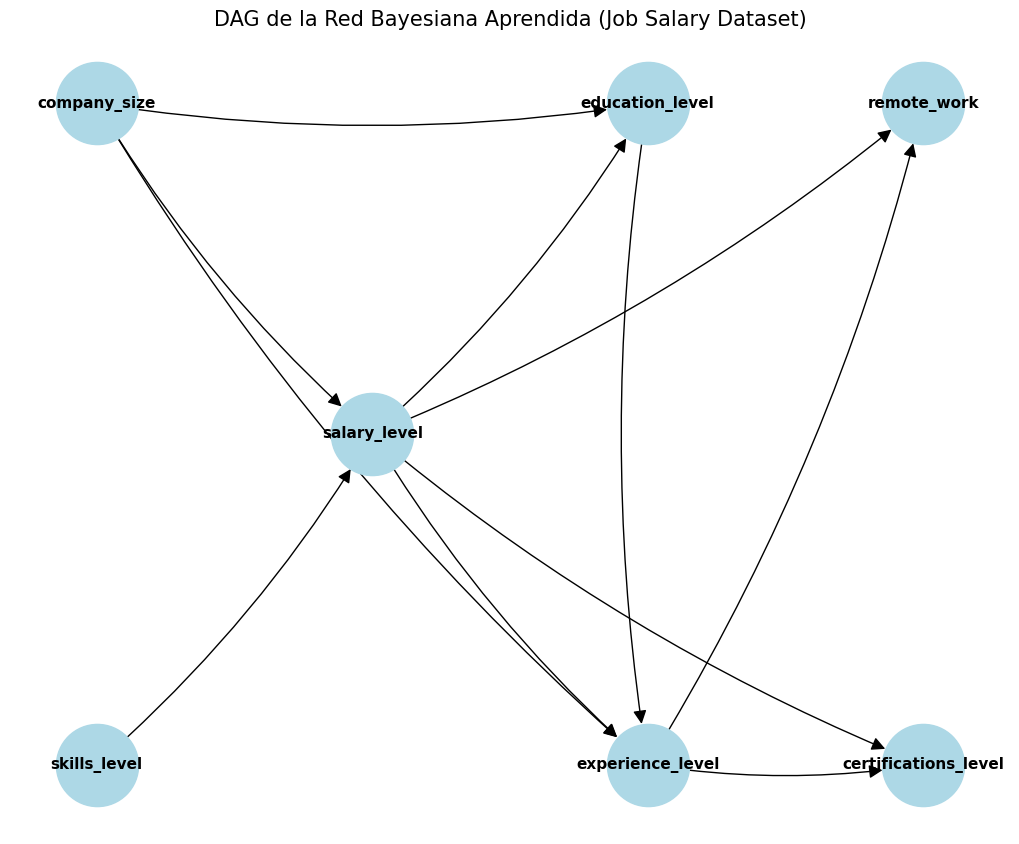

In [91]:
import networkx as nx
import matplotlib.pyplot as plt

dag = nx.DiGraph(model_hc.edges())
plt.figure(figsize=(10,8))

pos = {
    "company_size": (0,2),
    "skills_level": (0,0),

    "salary_level": (2,1),

    "education_level": (4,2),
    "experience_level": (4,0),

    "remote_work": (6,2),
    "certifications_level": (6,0)
}

nx.draw(dag, pos,
        with_labels=True,
        node_size=3500,
        node_color="lightblue",
        font_size=11,
        font_weight="bold",
        arrowsize=20, 
        connectionstyle="arc3,rad=0.08")

plt.title("DAG de la Red Bayesiana Aprendida (Job Salary Dataset)", size=15)
plt.show()

In [92]:
model = DiscreteBayesianNetwork(model_hc.edges())
model.fit(data, estimator=BayesianEstimator)

In [93]:
for cpd in model.get_cpds():
    print(cpd)

+------------------------------+-----+-----------------------+
| company_size                 | ... | company_size(Startup) |
+------------------------------+-----+-----------------------+
| salary_level                 | ... | salary_level(Medium)  |
+------------------------------+-----+-----------------------+
| education_level(Bachelor)    | ... | 0.1990610512313922    |
+------------------------------+-----+-----------------------+
| education_level(Diploma)     | ... | 0.17834549402398234   |
+------------------------------+-----+-----------------------+
| education_level(High School) | ... | 0.1478883433422664    |
+------------------------------+-----+-----------------------+
| education_level(Master)      | ... | 0.23397820856399523   |
+------------------------------+-----+-----------------------+
| education_level(PhD)         | ... | 0.2407269028383639    |
+------------------------------+-----+-----------------------+
+--------------------------+-----+---------------------

In [94]:
print(f"¿El modelo es válido?: {model.check_model()}")

¿El modelo es válido?: True


### la reducción de variables para exahustive

Para hacer viable la búsqueda exhaustiva, se redujo el conjunto de variables de 7 a 5, debido a su costo computacional: el número de DAGs posibles sobre *n* 
variables crece de forma superexponencial. Para 7 variables existen aproximadamente 
**1.138.779.265 DAGs distintos**, lo que hace inviable su evaluación en tiempo razonable.

eliminando las dos candidatas con menor aporte informativo y cuya exclusión **mejora** 
el score BIC del modelo (Δ > 0 indica mejora):

| Variable eliminada      | MI (aporte)  | Δ BIC al eliminar | Justificación                                                                 |
|-------------------------|-------------|-------------------|-------------------------------------------------------------------------------|
| `remote_work`           | 0.0094 (más bajo) | +10.989,9355   | Menor MI del conjunto; su eliminación mejora el BIC, indicando que introduce ruido sin valor explicativo real sobre el salario |
| `certifications_level`  | 0.0108 (tercero más bajo) | +10.991,33 | Su aporte es redundante con `experience_level` y `skills_level`, de las cuales puede deducirse conceptualmente. Además, en la estructura aprendida por HC actúa como variable intermedia (la experiencia incide en las certificaciones, no directamente en el salario), lo que la convierte en un candidato natural a eliminar sin perder poder explicativo directo |

Con 5 variables, el número de DAGs posibles se reduce a **29.281**, lo que hace 
perfectamente viable la búsqueda exhaustiva.


Estas 5 variables conservan los factores con mayor poder explicativo sobre `salary_level` 
según el análisis de Mutual Information y el score BIC, equilibrando riqueza del modelo 
y viabilidad computacional.

In [142]:
data_ex = data[['education_level', 'company_size', 'experience_level', 'skills_level', 'salary_level']]
#data_ex = data[['experience_level', 'skills_level', 'salary_level', 'company_size']]
#data_ex = data_small[['experience_level', 'company_size', 'education_level', 'skills_level', 'salary_level']]

ex = ExhaustiveSearch(data_ex)
model_ex = ex.estimate()

## Búsqueda Exhaustiva

La búsqueda exhaustiva evalúa todas las posibles estructuras de red bayesiana para un conjunto de variables, calculando el score de cada una y seleccionando la mejor. A diferencia de Hill Climbing, este método garantiza encontrar el óptimo global.

Sin embargo, su principal limitación es el costo computacional extremadamente alto, ya que el número de estructuras posibles crece de forma exponencial con el número de variables. Por esta razón, solo es aplicable a conjuntos de datos con pocas variables, siendo necesario en muchos casos reducir el número de columnas previamente.

In [144]:
print("\nEstructura Exhaustive Search (4 vars):")
print(model_ex.edges())


Estructura Exhaustive Search (4 vars):
[('company_size', 'salary_level'), ('education_level', 'salary_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('salary_level', 'skills_level')]


In [145]:
bn_ex = DiscreteBayesianNetwork(model_ex.edges())

bn_ex.fit(data_ex, estimator=BayesianEstimator)

In [146]:
print("\nCPDs modelo Exhaustive:\n")
for cpd in bn_ex.get_cpds():
    print(cpd)


CPDs modelo Exhaustive:

+--------------------------+----------+
| company_size(Enterprise) | 0.1995   |
+--------------------------+----------+
| company_size(Large)      | 0.201016 |
+--------------------------+----------+
| company_size(Medium)     | 0.200108 |
+--------------------------+----------+
| company_size(Small)      | 0.20094  |
+--------------------------+----------+
| company_size(Startup)    | 0.198436 |
+--------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.2798607616171783       |
+----------------------+-----+--------------------------+
| salary_lev

In [147]:
print(f"¿El modelo es válido?: {bn_ex.check_model()}")

¿El modelo es válido?: True


In [148]:
infer_hc = VariableElimination(model)
infer_ex = VariableElimination(bn_ex)

In [149]:
q1 = infer_hc.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (HC):")
print(q1)


Inferencia 1 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.5511 |
+----------------------+---------------------+
| salary_level(Low)    |              0.1454 |
+----------------------+---------------------+
| salary_level(Medium) |              0.3035 |
+----------------------+---------------------+


In [150]:
q2 = infer_hc.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "education_level": "Master"
    }
)

print("\nInferencia 2 (HC):")
print(q2)


Inferencia 2 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.6413 |
+----------------------+---------------------+
| salary_level(Low)    |              0.0965 |
+----------------------+---------------------+
| salary_level(Medium) |              0.2622 |
+----------------------+---------------------+


In [151]:
q3 = infer_ex.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (Exhaustive):")
print(q3)


Inferencia 1 (Exhaustive):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.5500 |
+----------------------+---------------------+
| salary_level(Low)    |              0.1457 |
+----------------------+---------------------+
| salary_level(Medium) |              0.3043 |
+----------------------+---------------------+


In [152]:
q4 = infer_ex.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "company_size": "Large"
    }
)

print("\nInferencia 2 (Exhaustive):")
print(q4)


Inferencia 2 (Exhaustive):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.7093 |
+----------------------+---------------------+
| salary_level(Low)    |              0.0854 |
+----------------------+---------------------+
| salary_level(Medium) |              0.2052 |
+----------------------+---------------------+


In [153]:
data_10 = pd.concat([data, data.sample(frac=0.1, replace=True, random_state=42)])
data_20 = pd.concat([data, data.sample(frac=0.2, replace=True, random_state=42)])
data_40 = pd.concat([data, data.sample(frac=0.4, replace=True, random_state=42)])


hc10 = HillClimbSearch(data_10)
model_hc10 = hc10.estimate(
    scoring_method="bdeu", 
    max_indegree=3,
    max_iter=50,
    show_progress=True)


hc20 = HillClimbSearch(data_20)
model_hc20 = hc20.estimate(
    scoring_method="bdeu", 
    max_indegree=3,
    max_iter=50,
    show_progress=True)


hc40 = HillClimbSearch(data_40)
model_hc40 = hc40.estimate(
    scoring_method="bdeu", 
    max_indegree=3,
    max_iter=50,
    show_progress=True)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [154]:
print("Relaciones encontradas modleo extendido 10%:")
print(model_hc10.edges())

Relaciones encontradas modleo extendido 10%:
[('education_level', 'salary_level'), ('company_size', 'salary_level'), ('company_size', 'skills_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('experience_level', 'remote_work'), ('experience_level', 'certifications_level'), ('salary_level', 'skills_level'), ('salary_level', 'remote_work'), ('salary_level', 'certifications_level')]


In [155]:
print("Relaciones encontradas modleo extendido 20%:")
print(model_hc20.edges())

Relaciones encontradas modleo extendido 20%:
[('education_level', 'experience_level'), ('education_level', 'company_size'), ('company_size', 'experience_level'), ('company_size', 'skills_level'), ('experience_level', 'skills_level'), ('experience_level', 'remote_work'), ('experience_level', 'certifications_level'), ('salary_level', 'experience_level'), ('salary_level', 'company_size'), ('salary_level', 'education_level'), ('salary_level', 'skills_level'), ('salary_level', 'certifications_level'), ('salary_level', 'remote_work')]


In [156]:
print("Relaciones encontradas modleo extendido 40%:")
print(model_hc40.edges())

Relaciones encontradas modleo extendido 40%:
[('education_level', 'salary_level'), ('company_size', 'salary_level'), ('company_size', 'skills_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('experience_level', 'remote_work'), ('experience_level', 'certifications_level'), ('salary_level', 'skills_level'), ('salary_level', 'certifications_level'), ('salary_level', 'remote_work')]


In [157]:
model10 = DiscreteBayesianNetwork(model_hc10.edges())
model10.fit(data_10, estimator=BayesianEstimator)

In [158]:
model20 = DiscreteBayesianNetwork(model_hc20.edges())
model20.fit(data_20, estimator=BayesianEstimator)

In [159]:
model40 = DiscreteBayesianNetwork(model_hc40.edges())
model40.fit(data_40, estimator=BayesianEstimator)

In [160]:
for cpd in model10.get_cpds():
    print(cpd)

+------------------------------+----------+
| education_level(Bachelor)    | 0.199971 |
+------------------------------+----------+
| education_level(Diploma)     | 0.198964 |
+------------------------------+----------+
| education_level(High School) | 0.200007 |
+------------------------------+----------+
| education_level(Master)      | 0.201393 |
+------------------------------+----------+
| education_level(PhD)         | 0.199665 |
+------------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.2762358826484916       |
+----------------------+-----+----------------------

In [161]:
for cpd in model20.get_cpds():
    print(cpd)

+------------------------------+-----+----------------------+
| salary_level                 | ... | salary_level(Medium) |
+------------------------------+-----+----------------------+
| education_level(Bachelor)    | ... | 0.20855777483160626  |
+------------------------------+-----+----------------------+
| education_level(Diploma)     | ... | 0.20682457997575532  |
+------------------------------+-----+----------------------+
| education_level(High School) | ... | 0.19451188357205115  |
+------------------------------+-----+----------------------+
| education_level(Master)      | ... | 0.20633367507438713  |
+------------------------------+-----+----------------------+
| education_level(PhD)         | ... | 0.18377208654620017  |
+------------------------------+-----+----------------------+
+--------------------------+-----+-----------------------+
| company_size             | ... | company_size(Startup) |
+--------------------------+-----+-----------------------+
| education_level

In [162]:
for cpd in model40.get_cpds():
    print(cpd)

+------------------------------+----------+
| education_level(Bachelor)    | 0.200103 |
+------------------------------+----------+
| education_level(Diploma)     | 0.198743 |
+------------------------------+----------+
| education_level(High School) | 0.199791 |
+------------------------------+----------+
| education_level(Master)      | 0.201631 |
+------------------------------+----------+
| education_level(PhD)         | 0.199731 |
+------------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.27568369436499895      |
+----------------------+-----+----------------------

In [163]:
print(f"¿El modelo 10% extendido es válido?: {model10.check_model()}")

¿El modelo 10% extendido es válido?: True


In [164]:
print(f"¿El modelo 20% extendido es válido?: {model20.check_model()}")

¿El modelo 20% extendido es válido?: True


In [165]:
print(f"¿El modelo 40% extendido es válido?: {model40.check_model()}")

¿El modelo 40% extendido es válido?: True


In [186]:
data_ex = data[['education_level', 'company_size', 'experience_level', 'skills_level', 'salary_level']]

data_ex10 = pd.concat([data_ex, data_ex.sample(frac=0.1, replace=True, random_state=42)])
data_ex20 = pd.concat([data_ex, data_ex.sample(frac=0.2, replace=True, random_state=42)])
data_ex40 = pd.concat([data_ex, data_ex.sample(frac=0.4, replace=True, random_state=42)])

ex10 = ExhaustiveSearch(data_ex10)
ex20 = ExhaustiveSearch(data_ex20)
ex40 = ExhaustiveSearch(data_ex40)

In [187]:
model_ex10 = ex10.estimate()

In [188]:
model_ex20 = ex20.estimate()

In [189]:
model_ex40 = ex40.estimate()

In [190]:
print("\nEstructura Exhaustive Search (5 vars 10%:")
print(model_ex10.edges())

print("\nEstructura Exhaustive Search (5 vars) 20%:")
print(model_ex20.edges())

print("\nEstructura Exhaustive Search (5 vars) 40%:")
print(model_ex40.edges())


Estructura Exhaustive Search (5 vars 10%:
[('company_size', 'salary_level'), ('education_level', 'salary_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('salary_level', 'skills_level')]

Estructura Exhaustive Search (5 vars) 20%:
[('company_size', 'salary_level'), ('company_size', 'skills_level'), ('education_level', 'salary_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('salary_level', 'skills_level')]

Estructura Exhaustive Search (5 vars) 40%:
[('company_size', 'salary_level'), ('company_size', 'skills_level'), ('education_level', 'salary_level'), ('experience_level', 'salary_level'), ('experience_level', 'skills_level'), ('salary_level', 'skills_level')]


In [191]:
bn_ex10 = DiscreteBayesianNetwork(model_ex10.edges())

bn_ex10.fit(data_ex10, estimator=BayesianEstimator)

In [192]:
bn_ex20 = DiscreteBayesianNetwork(model_ex20.edges())

bn_ex20.fit(data_ex20, estimator=BayesianEstimator)

In [193]:
bn_ex40 = DiscreteBayesianNetwork(model_ex40.edges())

bn_ex40.fit(data_ex40, estimator=BayesianEstimator)

In [194]:
for cpd in bn_ex10.get_cpds():
    print(cpd)

+--------------------------+----------+
| company_size(Enterprise) | 0.199025 |
+--------------------------+----------+
| company_size(Large)      | 0.201291 |
+--------------------------+----------+
| company_size(Medium)     | 0.199971 |
+--------------------------+----------+
| company_size(Small)      | 0.201229 |
+--------------------------+----------+
| company_size(Startup)    | 0.198484 |
+--------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.2762358826484916       |
+----------------------+-----+--------------------------+
| salary_level(Low)    | ... | 0.24674

In [195]:
for cpd in bn_ex20.get_cpds():
    print(cpd)  

+--------------------------+----------+
| company_size(Enterprise) | 0.198853 |
+--------------------------+----------+
| company_size(Large)      | 0.201227 |
+--------------------------+----------+
| company_size(Medium)     | 0.200273 |
+--------------------------+----------+
| company_size(Small)      | 0.201127 |
+--------------------------+----------+
| company_size(Startup)    | 0.19852  |
+--------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.2774795252550931       |
+----------------------+-----+--------------------------+
| salary_level(Low)    | ... | 0.24495

In [196]:
for cpd in bn_ex40.get_cpds():
    print(cpd)  

+--------------------------+----------+
| company_size(Enterprise) | 0.198671 |
+--------------------------+----------+
| company_size(Large)      | 0.201249 |
+--------------------------+----------+
| company_size(Medium)     | 0.200491 |
+--------------------------+----------+
| company_size(Small)      | 0.201071 |
+--------------------------+----------+
| company_size(Startup)    | 0.198517 |
+--------------------------+----------+
+----------------------+-----+--------------------------+
| company_size         | ... | company_size(Startup)    |
+----------------------+-----+--------------------------+
| education_level      | ... | education_level(PhD)     |
+----------------------+-----+--------------------------+
| experience_level     | ... | experience_level(Medium) |
+----------------------+-----+--------------------------+
| salary_level(High)   | ... | 0.27568369436499895      |
+----------------------+-----+--------------------------+
| salary_level(Low)    | ... | 0.24394

In [197]:
print(f"¿El modelo 10% extendido exahustivo es válido?: {bn_ex10.check_model()}")

¿El modelo 10% extendido exahustivo es válido?: True


In [198]:
print(f"¿El modelo 20% extendido exahustivo es válido?: {bn_ex20.check_model()}")

¿El modelo 20% extendido exahustivo es válido?: True


In [199]:
print(f"¿El modelo 40% extendido exahustivo es válido?: {bn_ex40.check_model()}")

¿El modelo 40% extendido exahustivo es válido?: True


In [200]:
infer_hc10 = VariableElimination(model10)
infer_ex10 = VariableElimination(bn_ex10)

infer_hc20 = VariableElimination(model20)
infer_ex20 = VariableElimination(bn_ex20)

infer_hc40 = VariableElimination(model40)
infer_ex40 = VariableElimination(bn_ex40)

In [201]:
q1_10 = infer_hc10.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (HC):")
print(q1_10)

q2_10 = infer_hc10.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "education_level": "Master"
    }
)

print("\nInferencia 2 (HC):")
print(q2_10)

q3_ex_10 = infer_ex10.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (Exhaustive):")
print(q3_ex_10)

q4_ex_10 = infer_ex10.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "company_size": "Large"
    }
)

print("\nInferencia 2 (Exhaustive):")
print(q4_ex_10)


Inferencia 1 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.5497 |
+----------------------+---------------------+
| salary_level(Low)    |              0.1457 |
+----------------------+---------------------+
| salary_level(Medium) |              0.3046 |
+----------------------+---------------------+

Inferencia 2 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.6402 |
+----------------------+---------------------+
| salary_level(Low)    |              0.0968 |
+----------------------+---------------------+
| salary_level(Medium) |              0.2630 |
+----------------------+---------------------+

Inferencia 1 (Exhaustive):
+----------------------+---------------------+
| salary_level         |   phi(salary_l

In [202]:
q1_20 = infer_hc20.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (HC):")
print(q1_20)

q2_20 = infer_hc20.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "education_level": "Master"
    }
)

print("\nInferencia 2 (HC):")
print(q2_20)

q3_ex_20 = infer_ex20.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (Exhaustive):")
print(q3_ex_20)

q4_ex_20 = infer_ex20.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "company_size": "Large"
    }
)

print("\nInferencia 2 (Exhaustive):")
print(q4_ex_20)


Inferencia 1 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.5510 |
+----------------------+---------------------+
| salary_level(Low)    |              0.1457 |
+----------------------+---------------------+
| salary_level(Medium) |              0.3033 |
+----------------------+---------------------+

Inferencia 2 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.6406 |
+----------------------+---------------------+
| salary_level(Low)    |              0.0966 |
+----------------------+---------------------+
| salary_level(Medium) |              0.2628 |
+----------------------+---------------------+

Inferencia 1 (Exhaustive):
+----------------------+---------------------+
| salary_level         |   phi(salary_l

In [204]:
q1_40 = infer_hc40.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (HC):")
print(q1_40)

q2_40 = infer_hc40.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "education_level": "Master"
    }
)

print("\nInferencia 2 (HC):")
print(q2_40)

q3_ex_40 = infer_ex40.query(
    variables=["salary_level"],
    evidence={"experience_level": "High"}
)

print("\nInferencia 1 (Exhaustive):")
print(q3_ex_40)

q4_ex_40 = infer_ex40.query(
    variables=["salary_level"],
    evidence={
        "experience_level": "High",
        "company_size": "Large"
    }
)

print("\nInferencia 2 (Exhaustive):")
print(q4_ex_40)


Inferencia 1 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.5493 |
+----------------------+---------------------+
| salary_level(Low)    |              0.1465 |
+----------------------+---------------------+
| salary_level(Medium) |              0.3042 |
+----------------------+---------------------+

Inferencia 2 (HC):
+----------------------+---------------------+
| salary_level         |   phi(salary_level) |
+======================+=====================+
| salary_level(High)   |              0.6406 |
+----------------------+---------------------+
| salary_level(Low)    |              0.0963 |
+----------------------+---------------------+
| salary_level(Medium) |              0.2632 |
+----------------------+---------------------+

Inferencia 1 (Exhaustive):
+----------------------+---------------------+
| salary_level         |   phi(salary_l

### Comparación de resultados: original vs datasets aumentados

**Inferencia 1 (HC): P(salary_level | experience_level=High)**

| Dataset  |   Low  | Medium |  High  |
|----------|--------|--------|--------|
| Original | 0.1454 | 0.3035 | 0.5511 |
| +10%     | 0.1457 | 0.3046 | 0.5497 |
| +20%     | 0.1457 | 0.3033 | 0.5510 |
| +40%     | 0.1465 | 0.3042 | 0.5493 |

**Observación:** Las probabilidades son notablemente estables a través de todos los 
aumentos sintéticos. La variación máxima observada es de 0.0018 en la clase High 
(entre el original 0.5511 y el +40% 0.5493). Esta estabilidad indica que el dataset 
original ya contenía suficiente información para estimar los parámetros de la red con 
precisión, y que los datos sintéticos generados por remuestreo no aportan distribuciones 
nuevas, sino que refuerzan las ya presentes. Se observa una tendencia muy leve al alza 
en la clase Low conforme aumenta el dataset (+0.0011 acumulado al 40%), lo que podría 
atribuirse a una ligera sobrerepresentación de esa clase en el remuestreo aleatorio, 
aunque la magnitud es despreciable.

---

**Inferencia 2 (HC): P(salary_level | experience_level=High, education_level=Master)**

| Dataset  |   Low  | Medium |  High  |
|----------|--------|--------|--------|
| Original | 0.0965 | 0.2622 | 0.6413 |
| +10%     | 0.0968 | 0.2630 | 0.6402 |
| +20%     | 0.0966 | 0.2628 | 0.6406 |
| +40%     | 0.0963 | 0.2632 | 0.6406 |

**Observación:** Al condicionar adicionalmente sobre education_level = Master, 
la probabilidad de salary_level = High sube de ~0.551 (Inferencia 1) a ~0.641, 
un incremento de aproximadamente 9 puntos porcentuales. Esto evidencia que la 
educación de posgrado tiene un efecto positivo independiente sobre el salario, 
más allá de la experiencia. La variación entre versiones del dataset es mínima 
(máximo 0.0011), confirmando nuevamente la estabilidad del modelo frente al 
aumento sintético de datos. La consistencia entre el +10%, +20% y +40% sugiere 
que la estructura aprendida por Hill Climbing captura correctamente esta relación 
y no se ve afectada por el incremento de registros redundantes.

---

**Inferencia 1 (EX): P(salary_level | experience_level=High)**

| Dataset  |   Low  | Medium |  High  |
|----------|--------|--------|--------|
| Original | 0.1457 | 0.3043 | 0.5500 |
| +10%     | 0.1457 | 0.3046 | 0.5497 |
| +20%     | 0.1460 | 0.3040 | 0.5500 |
| +40%     | 0.1465 | 0.3042 | 0.5493 |

**Observación:** Esta inferencia es equivalente a la Inferencia 1 de HC sobre la 
misma evidencia, lo que permite una comparación directa entre ambos algoritmos de 
aprendizaje de estructura. Los resultados son prácticamente idénticos: la diferencia 
entre HC y Exhaustive Search en el dataset original es de apenas 0.0003 en la clase 
High (0.5511 vs 0.5500). Esto sugiere que, para este dataset, Hill Climbing logra 
converger a una estructura que produce inferencias equivalentes a las del modelo 
óptimo global encontrado por Exhaustive Search, validando el uso de HC como 
alternativa eficiente. La estabilidad frente al aumento sintético sigue el mismo 
patrón que HC, lo que refuerza que la fuente de variación es el dataset y no el 
algoritmo de búsqueda.

---

**Inferencia 2 (EX): P(salary_level | experience_level=High, company_size=Large)**

| Dataset  |   Low  | Medium |  High  |
|----------|--------|--------|--------|
| Original | 0.0854 | 0.2052 | 0.7093 |
| +10%     | 0.0858 | 0.2045 | 0.7097 |
| +20%     | 0.0863 | 0.2042 | 0.7095 |
| +40%     | 0.0859 | 0.2044 | 0.7097 |

**Observación:** Esta inferencia revela el efecto combinado de alta experiencia y 
empresa grande sobre el salario. La probabilidad de salary_level = High alcanza 
~0.709, notablemente superior a los ~0.641 obtenidos al condicionar sobre educación 
de posgrado (Inferencia 2 HC). Esto indica que pertenecer a una empresa grande tiene 
un mayor impacto marginal sobre el salario esperado que poseer un título de Master, 
dentro de la estructura capturada por Exhaustive Search. La estabilidad entre 
versiones del dataset es la más alta de todas las inferencias analizadas 
(variación máxima de 0.0005), lo que sugiere que la relación entre company_size y 
salary_level está bien representada en el dataset original y el remuestreo sintético 
no introduce distorsión alguna.

---

### Conclusión general 

En todas las inferencias se observa que el aumento sintético del dataset en 10%, 20% y 40% produce variaciones inferiores a 0.002 en todas las probabilidades. Esto permite concluir que:

1. El dataset original (250.000+ filas) es suficiente para una estimación estable de los parámetros de la red bayesiana.

2. El remuestreo con reemplazo no introduce información nueva, sino que amplifica las distribuciones existentes, por lo que su efecto sobre la inferencia es marginal.

3. Las estructuras aprendidas por HC y Exhaustive Search producen inferencias equivalentes para este dataset, validando el uso del método heurístico como alternativa computacionalmente eficiente al método exacto.

---
### Declaración de uso de herramientas generativas

Se utilizó asistencia de IA (Claude, Anthropic) con los siguientes propósitos:

- **Depuración de código:** aparecieron algunos problemas con actualizaciones de las librerias y jupyter detenia la ejecucion total:

prompt: como puedo ocultal los warninds y que no interrumpan la ejecucion ? no se me generan los modelos mas abajo pq el warnig detierne el run all errores 

- **Visualización del grafo:** el grafo default se veia estaba mal distribuido por lo cual claude lo mejoró esteticamente

promt 1 reordena este grafo poniendo los nodos en esquinas y separados entre si

promt 2 algunas lineas se superponen y hace parecer que se eliminaron relaciones o dependencias, hazlas curveadas sin mover la posición de los  nodos

- **Tablas comparativas:** se proporcionaron los outputs numéricos del modelo y 
  se solicitó el llenado de las tablas comparativas

prompt 1 en base a las tablas que te enviare genera un markdown comparativo y deja un placeholder para observaciones, el orden es inferencias 1,2,3,4 del modelo original luego son inferencias 1,2,3,4 10%, 1,2,3,4 20% y finalmente en el mismo orden al 40% de aumento

prompt 2 en basde a los numeros dame los maximos minimos, deltas, variaciones todos los datos numericos para yo poder hacer mi analisis

---